# **1. Perkenalan Dataset**


## Titanic Dataset

**Sumber Dataset:** [Kaggle - Titanic: Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/data)

**Deskripsi:**  
Dataset Titanic berisi data penumpang kapal RMS Titanic yang tenggelam pada 15 April 1912. Dataset ini merupakan salah satu dataset paling populer untuk belajar machine learning, khususnya untuk kasus klasifikasi biner.

**Fitur-fitur dalam dataset:**
| Fitur | Deskripsi | Tipe |
|---|---|---|
| `PassengerId` | ID unik setiap penumpang | Integer |
| `Survived` | Apakah selamat (0=Tidak, 1=Ya) | Integer (Target) |
| `Pclass` | Kelas tiket (1=1st, 2=2nd, 3=3rd) | Integer |
| `Name` | Nama penumpang | String |
| `Sex` | Jenis kelamin | String |
| `Age` | Usia penumpang | Float |
| `SibSp` | Jumlah saudara/pasangan di kapal | Integer |
| `Parch` | Jumlah orang tua/anak di kapal | Integer |
| `Ticket` | Nomor tiket | String |
| `Fare` | Harga tiket | Float |
| `Cabin` | Nomor kabin | String |
| `Embarked` | Pelabuhan keberangkatan (C/Q/S) | String |

**Target (label):**
- `0` = Tidak selamat
- `1` = Selamat

**Tujuan:** Membangun model klasifikasi biner untuk memprediksi apakah seorang penumpang selamat atau tidak berdasarkan karakteristik demografis dan informasi perjalanan.

# **2. Import Library**

Pada tahap ini, kita mengimpor pustaka Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [27]:
# ── Data Manipulation ──────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing ──────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── Settings ───────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

print('Semua library berhasil diimport!')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')

Semua library berhasil diimport!
Pandas  : 2.3.3
NumPy   : 2.4.2


# **3. Memuat Dataset**

Dataset Titanic dimuat langsung menggunakan library `seaborn` yang sudah menyediakan dataset ini secara built-in, sehingga tidak perlu mengunduh manual dari Kaggle. Struktur dan isi datanya identik dengan versi Kaggle.

In [28]:
df = pd.read_csv('../titanic_raw/training.csv')

print('Dataset Titanic berhasil dimuat!')
print(f'Ukuran dataset : {df.shape[0]} baris x {df.shape[1]} kolom')
print()
print('5 baris pertama:')
df.head()

Dataset Titanic berhasil dimuat!
Ukuran dataset : 891 baris x 12 kolom

5 baris pertama:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
# Simpan dataset raw ke CSV
df.to_csv('titanic_raw.csv', index=False)
print('Dataset raw disimpan sebagai titanic_raw.csv')

Dataset raw disimpan sebagai titanic_raw.csv


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset Titanic.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [30]:
# ── 4.1 Informasi Umum Dataset ─────────────────────────────────
print('=' * 55)
print('INFORMASI UMUM DATASET')
print('=' * 55)
df.info()

INFORMASI UMUM DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [31]:
# Tambahkan ini di awal cell preprocessing
fitur_numerik = ['Age', 'Fare', 'SibSp', 'Parch']
fitur_outlier = ['Age', 'Fare', 'SibSp', 'Parch']

In [32]:
# ── 4.2 Statistik Deskriptif ───────────────────────────────────
print('STATISTIK DESKRIPTIF')
print('=' * 55)
df.describe().round(2)

STATISTIK DESKRIPTIF


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


CEK MISSING VALUES
          Jumlah Missing  Persentase (%)
Cabin                687           77.10
Age                  177           19.87
Embarked               2            0.22

Total missing values: 866


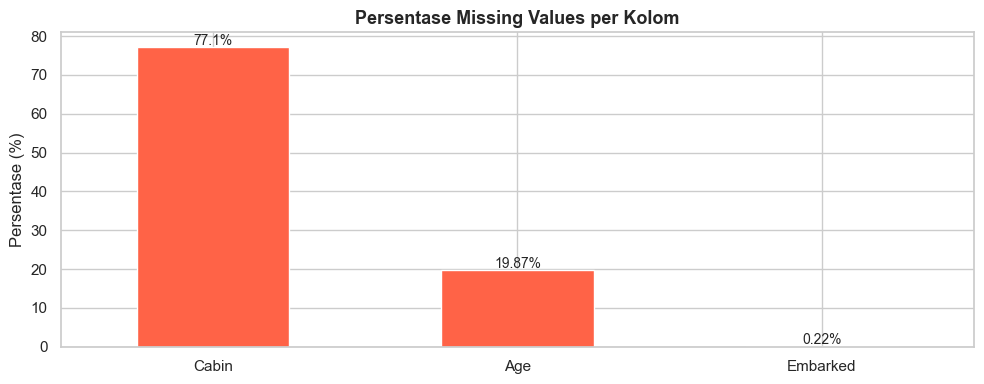

In [33]:
# ── 4.3 Cek Missing Values ─────────────────────────────────────
print('CEK MISSING VALUES')
print('=' * 55)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).sort_values('Jumlah Missing', ascending=False)
print(missing_df[missing_df['Jumlah Missing'] > 0])
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

# Visualisasi missing values
plt.figure(figsize=(10, 4))
missing_plot = missing_df[missing_df['Jumlah Missing'] > 0]['Persentase (%)']
missing_plot.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Persentase Missing Values per Kolom', fontsize=13, fontweight='bold')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
for i, v in enumerate(missing_plot):
    plt.text(i, v + 0.5, f'{v}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

DISTRIBUSI KELAS TARGET (Survived)
Survived
Tidak Selamat    549
Selamat          342
Name: count, dtype: int64

Survival rate: 38.4%


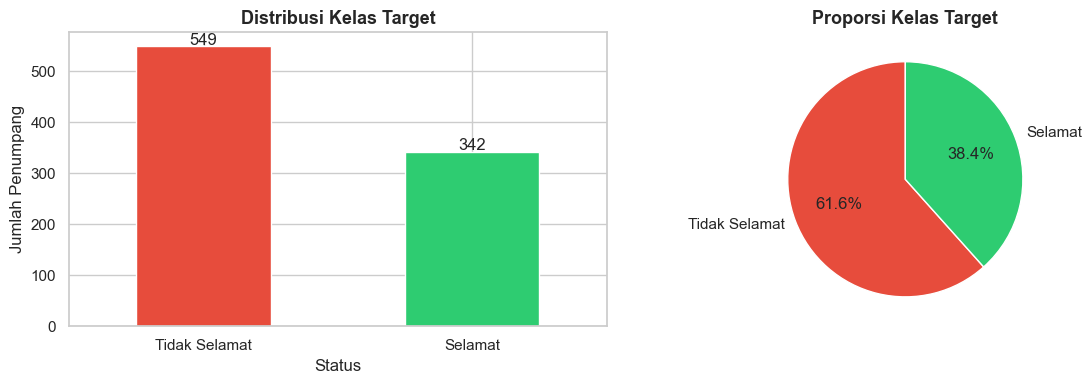

In [34]:
# ── 4.4 Distribusi Kelas Target (Survived) ─────────────────────
print('DISTRIBUSI KELAS TARGET (Survived)')
print('=' * 55)
label_map = {0: 'Tidak Selamat', 1: 'Selamat'}
print(df['Survived'].map(label_map).value_counts())
print(f"\nSurvival rate: {df['Survived'].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#E74C3C', '#2ECC71']
df['Survived'].map(label_map).value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white', rot=0)
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Penumpang')
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()+3), ha='center')

df['Survived'].map(label_map).value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=colors, startangle=90)
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

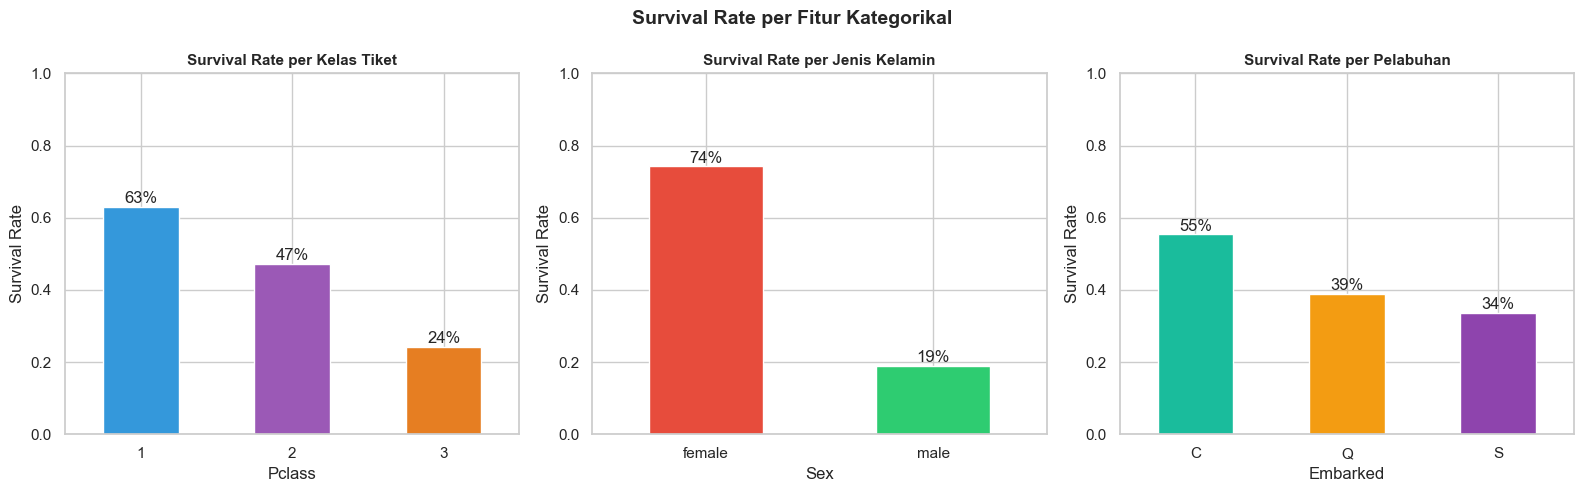

Insight:
- Penumpang kelas 1 memiliki survival rate tertinggi
- Wanita jauh lebih banyak selamat dibanding pria
- Penumpang dari Cherbourg memiliki survival rate lebih tinggi


In [35]:
# ── 4.5 Survival Rate per Fitur Kategorikal ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Per kelas tiket
df.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', ax=axes[0], color=['#3498DB','#9B59B6','#E67E22'], rot=0)
axes[0].set_title('Survival Rate per Kelas Tiket', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0%}',
        (p.get_x() + p.get_width()/2, p.get_height()+0.01), ha='center')

# Per jenis kelamin
df.groupby('Sex')['Survived'].mean().plot(
    kind='bar', ax=axes[1], color=['#E74C3C','#2ECC71'], rot=0)
axes[1].set_title('Survival Rate per Jenis Kelamin', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0%}',
        (p.get_x() + p.get_width()/2, p.get_height()+0.01), ha='center')

# Per pelabuhan keberangkatan
df.groupby('Embarked')['Survived'].mean().plot(
    kind='bar', ax=axes[2], color=['#1ABC9C','#F39C12','#8E44AD'], rot=0)
axes[2].set_title('Survival Rate per Pelabuhan', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Survival Rate')
axes[2].set_ylim(0, 1)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.0%}',
        (p.get_x() + p.get_width()/2, p.get_height()+0.01), ha='center')

plt.suptitle('Survival Rate per Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight:')
print('- Penumpang kelas 1 memiliki survival rate tertinggi')
print('- Wanita jauh lebih banyak selamat dibanding pria')
print('- Penumpang dari Cherbourg memiliki survival rate lebih tinggi')

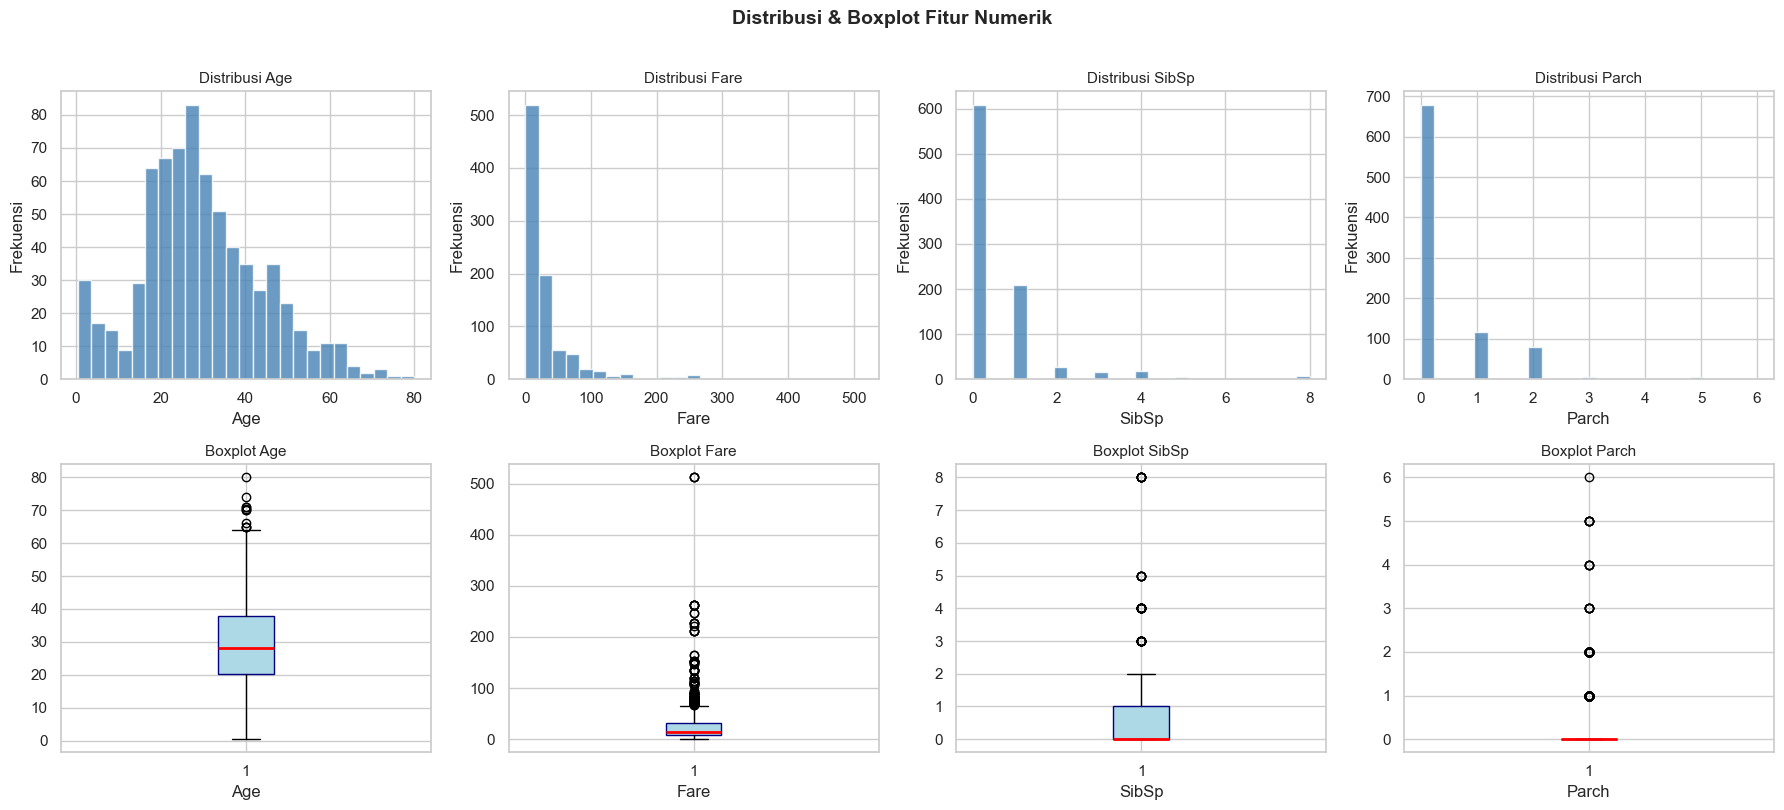

In [36]:
# ── 4.6 Distribusi Fitur Numerik ───────────────────────────────
fitur_numerik = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(fitur_numerik):
    axes[0, i].hist(df[col].dropna(), bins=25, color='steelblue',
                    edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'Distribusi {col}', fontsize=11)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')

    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='navy'),
        medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'Boxplot {col}', fontsize=11)
    axes[1, i].set_xlabel(col)

plt.suptitle('Distribusi & Boxplot Fitur Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

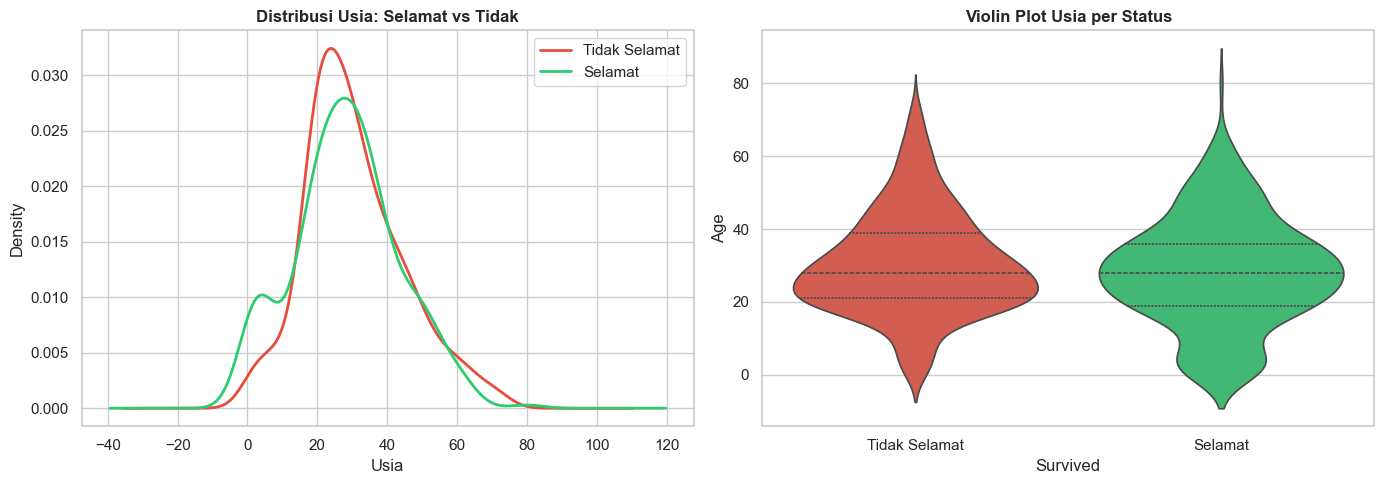

In [37]:
# ── 4.7 Distribusi Usia per Status Survived ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
for val, label, color in zip([0, 1], ['Tidak Selamat', 'Selamat'], ['#E74C3C', '#2ECC71']):
    df[df['Survived'] == val]['Age'].dropna().plot(
        kind='kde', ax=axes[0], label=label, color=color, linewidth=2)
axes[0].set_title('Distribusi Usia: Selamat vs Tidak', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Usia')
axes[0].legend()

# Violin
sns.violinplot(data=df, x='Survived', y='Age', palette=['#E74C3C','#2ECC71'],
               ax=axes[1], inner='quartile')
axes[1].set_xticklabels(['Tidak Selamat', 'Selamat'])
axes[1].set_title('Violin Plot Usia per Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

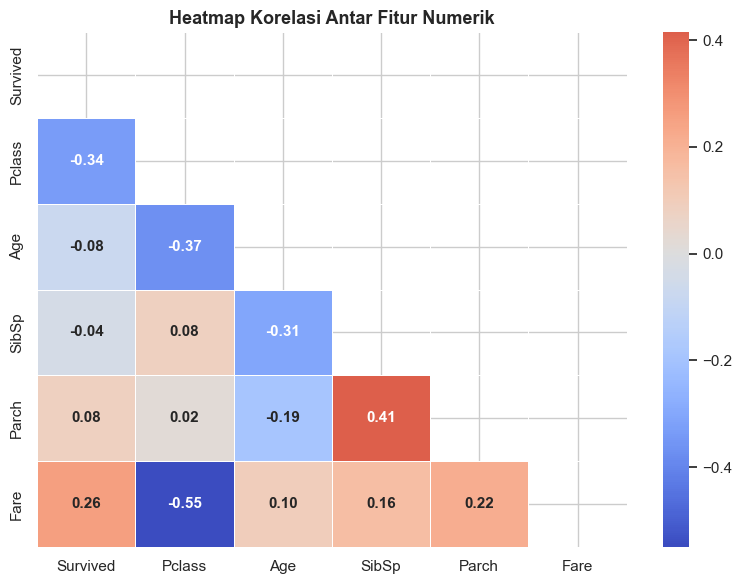

Insight:
- pclass berkorelasi NEGATIF dengan Survived (-0.34): kelas lebih rendah, survival rate turun
- Fare berkorelasi POSITIF dengan Survived (0.26): tiket mahal, peluang selamat lebih besar
- Age berkorelasi negatif lemah dengan Survived (-0.08)


In [38]:
# ── 4.8 Heatmap Korelasi ───────────────────────────────────────
fitur_corr = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

plt.figure(figsize=(8, 6))
corr_matrix = df[fitur_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5,
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Insight:')
print('- pclass berkorelasi NEGATIF dengan Survived (-0.34): kelas lebih rendah, survival rate turun')
print('- Fare berkorelasi POSITIF dengan Survived (0.26): tiket mahal, peluang selamat lebih besar')
print('- Age berkorelasi negatif lemah dengan Survived (-0.08)')

# **5. Data Preprocessing**

Pada tahap ini kita melakukan preprocessing data sebelum digunakan untuk melatih model machine learning. Tahapan yang dilakukan:
1. Menghapus Kolom Tidak Relevan
2. Menangani Missing Values
3. Menghapus Duplikat
4. Deteksi dan Penanganan Outlier
5. Encoding Fitur Kategorikal
6. Standarisasi Fitur Numerik
7. Train-Test Split

In [39]:
df_clean = df.copy()
print(f'Kolom tersisa : {list(df_clean.columns)}')
print(f'Ukuran dataset: {df_clean.shape}')

Kolom tersisa : ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Ukuran dataset: (891, 12)


In [40]:
# ── 5.2 Menangani Missing Values ───────────────────────────────
print('STEP 2: Menangani Missing Values')
print('=' * 55)

print('Missing values sebelum:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# 'Age'      : isi dengan median per kelas tiket (lebih representatif)
df_clean['Age'] = df_clean.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)

# 'embarked' : isi dengan modus (nilai paling sering)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

print('\nMissing values sesudah:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print(f'\nTotal missing values: {df_clean.isnull().sum().sum()}')

STEP 2: Menangani Missing Values
Missing values sebelum:
Age         177
Cabin       687
Embarked      2
dtype: int64

Missing values sesudah:
Cabin    687
dtype: int64

Total missing values: 687


In [41]:
# ── 5.3 Menghapus Duplikat ─────────────────────────────────────
print('STEP 3: Menghapus Data Duplikat')
print('=' * 55)

n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
n_after = len(df_clean)

print(f'Jumlah baris sebelum    : {n_before}')
print(f'Jumlah duplikat dihapus : {n_before - n_after}')
print(f'Jumlah baris setelah    : {n_after}')

STEP 3: Menghapus Data Duplikat
Jumlah baris sebelum    : 891
Jumlah duplikat dihapus : 0
Jumlah baris setelah    : 891


In [42]:
# ── 5.4 Deteksi dan Penanganan Outlier (IQR Method) ────────────
print('STEP 4: Deteksi dan Penanganan Outlier')
print('=' * 55)

fitur_outlier = ['Age', 'Fare', 'SibSp', 'Parch']

for col in fitur_outlier:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outlier = len(df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)])
    print(f'{col:8s}: {n_outlier:3d} outlier | batas [{lower:.2f}, {upper:.2f}]')

    # Capping (Winsorization)
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print(f'\nUkuran dataset setelah penanganan outlier: {df_clean.shape}')

STEP 4: Deteksi dan Penanganan Outlier
Age     :  26 outlier | batas [-0.50, 59.50]
Fare    : 116 outlier | batas [-26.72, 65.63]
SibSp   :  46 outlier | batas [-1.50, 2.50]
Parch   : 213 outlier | batas [0.00, 0.00]

Ukuran dataset setelah penanganan outlier: (891, 12)


In [43]:
# ── 5.5 Encoding Fitur Kategorikal ─────────────────────────────
print('STEP 5: Encoding Fitur Kategorikal')
print('=' * 55)

le = LabelEncoder()

# Encoding 'Sex': male=1, female=0
df_clean['Sex_encoded'] = le.fit_transform(df_clean['Sex'])
print('Sex encoding    :', dict(zip(le.classes_, le.transform(le.classes_))))

# Encoding 'Embarked': C=0, Q=1, S=2
df_clean['Embarked_encoded'] = le.fit_transform(df_clean['Embarked'])
print('Embarked encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Feature engineering: FamilySize
df_clean['family_size'] = df_clean['SibSp'] + df_clean['Parch'] + 1
print('\nFitur baru ditambahkan: family_size (SibSp + Parch + 1)')

print(f'\nContoh data setelah encoding:')
df_clean[['Sex', 'Sex_encoded', 'Embarked', 'Embarked_encoded', 'family_size']].head()

STEP 5: Encoding Fitur Kategorikal
Sex encoding    : {'female': np.int64(0), 'male': np.int64(1)}
Embarked encoding: {'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2)}

Fitur baru ditambahkan: family_size (SibSp + Parch + 1)

Contoh data setelah encoding:


,Sex,Sex_encoded,Embarked,Embarked_encoded,family_size
0,male,1,S,2,2.0
1,female,0,C,0,2.0
2,female,0,S,2,1.0
3,female,0,S,2,2.0
4,male,1,S,2,1.0


In [44]:
# ── 5.6 Standarisasi Fitur Numerik ─────────────────────────────
print('STEP 6: Standarisasi Fitur Numerik')
print('=' * 55)

# Pilih fitur final untuk model
fitur_model = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
               'Sex_encoded', 'Embarked_encoded', 'family_size']
target = 'Survived'

X = df_clean[fitur_model].copy()
y = df_clean[target].copy()

# Scaling hanya pada fitur numerik kontinu
fitur_scale = ['Age', 'Fare', 'family_size']
scaler = StandardScaler()
X[fitur_scale] = scaler.fit_transform(X[fitur_scale])

print('Fitur yang di-scaling:', fitur_scale)
print()
print('Statistik setelah scaling:')
X[fitur_scale].describe().round(3)

STEP 6: Standarisasi Fitur Numerik
Fitur yang di-scaling: ['Age', 'Fare', 'family_size']

Statistik setelah scaling:


,Age,Fare,family_size
count,891.000,891.000,891.000
mean,0.000,0.000,-0.000
std,1.001,1.001,1.001
min,-2.227,-1.175,-0.603
25%,-0.540,-0.788,-0.603
50%,-0.227,-0.469,-0.603
75%,0.633,0.340,0.810
max,2.392,2.032,2.929


In [45]:
# ── 5.7 Train-Test Split ───────────────────────────────────────
print('STEP 7: Train-Test Split')
print('=' * 55)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Total data         : {len(X)}')
print(f'Data training (80%): {len(X_train)}')
print(f'Data testing  (20%): {len(X_test)}')
print()
print('Distribusi kelas di training set:')
print(y_train.value_counts().rename({0:'Tidak Selamat', 1:'Selamat'}))
print()
print('Distribusi kelas di testing set:')
print(y_test.value_counts().rename({0:'Tidak Selamat', 1:'Selamat'}))

STEP 7: Train-Test Split
Total data         : 891
Data training (80%): 712
Data testing  (20%): 179

Distribusi kelas di training set:
Survived
Tidak Selamat    439
Selamat          273
Name: count, dtype: int64

Distribusi kelas di testing set:
Survived
Tidak Selamat    110
Selamat           69
Name: count, dtype: int64


In [46]:
# ── 5.8 Simpan Dataset yang Sudah Dipreprocess ─────────────────
import os
os.makedirs('titanic_preprocessing', exist_ok=True)

# Full dataset preprocessed
df_final = X.copy()
df_final['survived'] = y.values

# Split dataset
train_df = pd.concat([X_train.reset_index(drop=True),
                      y_train.reset_index(drop=True)], axis=1)
test_df  = pd.concat([X_test.reset_index(drop=True),
                      y_test.reset_index(drop=True)], axis=1)

df_final.to_csv('titanic_preprocessing/titanic_preprocessed.csv', index=False)
train_df.to_csv('titanic_preprocessing/titanic_train.csv', index=False)
test_df.to_csv('titanic_preprocessing/titanic_test.csv', index=False)

print('Dataset hasil preprocessing berhasil disimpan!')
print('File yang tersimpan:')
print('  - titanic_preprocessing/titanic_preprocessed.csv (full)')
print('  - titanic_preprocessing/titanic_train.csv        (80%)')
print('  - titanic_preprocessing/titanic_test.csv         (20%)')
print()
print('Preview titanic_preprocessed.csv:')
df_final.head()

Dataset hasil preprocessing berhasil disimpan!
File yang tersimpan:
  - titanic_preprocessing/titanic_preprocessed.csv (full)
  - titanic_preprocessing/titanic_train.csv        (80%)
  - titanic_preprocessing/titanic_test.csv         (20%)

Preview titanic_preprocessed.csv:


,Pclass,Age,SibSp,Parch,Fare,Sex_encoded,Embarked_encoded,family_size,survived
0,3,-0.539688,1.0,0,-0.820552,1,2,0.810220,0
1,1,0.711199,1.0,0,2.031623,0,0,0.810220,1
2,3,-0.226966,0.0,0,-0.787578,0,2,-0.602512,1
3,1,0.476658,1.0,0,1.419297,0,2,0.810220,1
4,3,0.476658,0.0,0,-0.781471,1,2,-0.602512,0


## Ringkasan Preprocessing

| Tahapan | Keterangan | Status |
|---|---|---|
| Hapus kolom tidak relevan | `deck`, `embark_town`, `who`, `alive`, `adult_male`, `alone` | ✅ |
| Missing Values | `Age` → median per pclass; `embarked` → modus | ✅ |
| Duplikat | Diperiksa dan dihapus | ✅ |
| Outlier | Capping IQR pada `Age`, `Fare`, `SibSp`, `Parch` | ✅ |
| Encoding | LabelEncoder pada `sex` dan `embarked` | ✅ |
| Feature Engineering | Tambah fitur `family_size` | ✅ |
| Scaling | StandardScaler pada `Age`, `Fare`, `family_size` | ✅ |
| Train-Test Split | 80% train / 20% test, stratified | ✅ |

Dataset sudah siap digunakan untuk pelatihan model machine learning.